# Graviton 4 (ARM) vs Xeon (x86): Lock Performance

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.size'] = 11

INT_COLS   = ['threads', 'cs_work', 'read_pct', 'total_ops', 'read_ops', 'write_ops']
FLOAT_COLS = ['ops_s', 'ns_op', 'fairness_min', 'fairness_max', 'fairness_ratio']

def resolve_csv(name):
    for base in [Path('.'), Path('results')]:
        if (base / name).exists(): return base / name
    raise FileNotFoundError(name)

def load_csv(path, platform):
    df = pd.read_csv(path, sep=';', decimal=',')
    for c in INT_COLS:   df[c] = pd.to_numeric(df[c], errors='coerce').astype('Int64')
    for c in FLOAT_COLS: df[c] = pd.to_numeric(df[c], errors='coerce')
    df['ops_s'] = df['ops_s'].astype(float)
    df['ops_m'] = df['ops_s'] / 1e6
    df['platform'] = platform
    return df

arm = load_csv(resolve_csv('arm_graviton_lockbench.csv'), 'arm')
x86 = load_csv(resolve_csv('x86_xeon_lockbench_new_rw_split.csv'), 'x86')
all_df = pd.concat([arm, x86], ignore_index=True)

SHARED_THREADS = sorted(set(arm['threads'].dropna().astype(int).unique()) &
                        set(x86['threads'].dropna().astype(int).unique()))

def agg(df, group_cols):
    return df.groupby(group_cols).agg(
        runs=('ops_m','size'), ops_m_mean=('ops_m','mean'), ops_m_std=('ops_m','std'),
        ns_mean=('ns_op','mean'), fair_mean=('fairness_ratio','mean'),
        fair_std=('fairness_ratio','std')
    ).reset_index()

LOCK_ORDER  = ['tas','ttas','cas','ticket','rw','occ','rcu']
LOCK_LABELS = {'tas':'TAS','ttas':'TTAS','cas':'CAS','ticket':'Ticket',
               'rw':'RW Lock','occ':'OCC','rcu':'RCU'}
LOCK_COLORS = {'tas':'#4e79a7','ttas':'#f28e2b','cas':'#e15759','ticket':'#76b7b2',
               'rw':'#59a14f','occ':'#af7aa1','rcu':'#ff9da7'}
PLAT_COLORS = {'arm':'#2ca02c', 'x86':'#1f77b4'}
PLAT_LABELS = {'arm':'Graviton 4 (ARM)', 'x86':'Xeon (x86)'}
PLAT_MARKER = {'arm':'s', 'x86':'o'}

# Prepare mutex aggregation
mutex = all_df[(all_df['workload']=='mutex') & (all_df['cs_work']==0) &
               (all_df['threads'].isin(SHARED_THREADS))].copy()
g_mutex = agg(mutex, ['platform','lock','threads']).sort_values(['lock','platform','threads'])
mutex_locks = [l for l in LOCK_ORDER if l in mutex['lock'].unique()]

# Prepare RW workload aggregation
rw_occ_rcu = all_df[(all_df['workload'].isin(['rw','rcu'])) &
                     (all_df['lock'].isin(['rw','occ','rcu'])) &
                     (all_df['threads'].isin(SHARED_THREADS))].copy()
g_rwl = agg(rw_occ_rcu, ['platform','lock','read_pct','threads'])

print(f'Shared threads: {SHARED_THREADS}')
print(f'Exclusive locks: {[LOCK_LABELS[l] for l in mutex_locks if l in ["tas","ttas","cas","ticket"]]}')
print(f'RW primitives:   {[LOCK_LABELS[l] for l in ["rw","occ","rcu"]]}')

Shared threads: [np.int64(1), np.int64(2), np.int64(4), np.int64(6), np.int64(8)]
Exclusive locks: ['TAS', 'TTAS', 'CAS', 'Ticket']
RW primitives:   ['RW Lock', 'OCC', 'RCU']


## 1. Exclusive Lock Throughput: Uncontended vs Contended

**Workload**: `lock() → unlock()` loop, single shared lock.
Left: uncontended (1T) — baseline latency dominates.
Right: contended (8T) — whichever lock handles cache-line thrashing best wins.

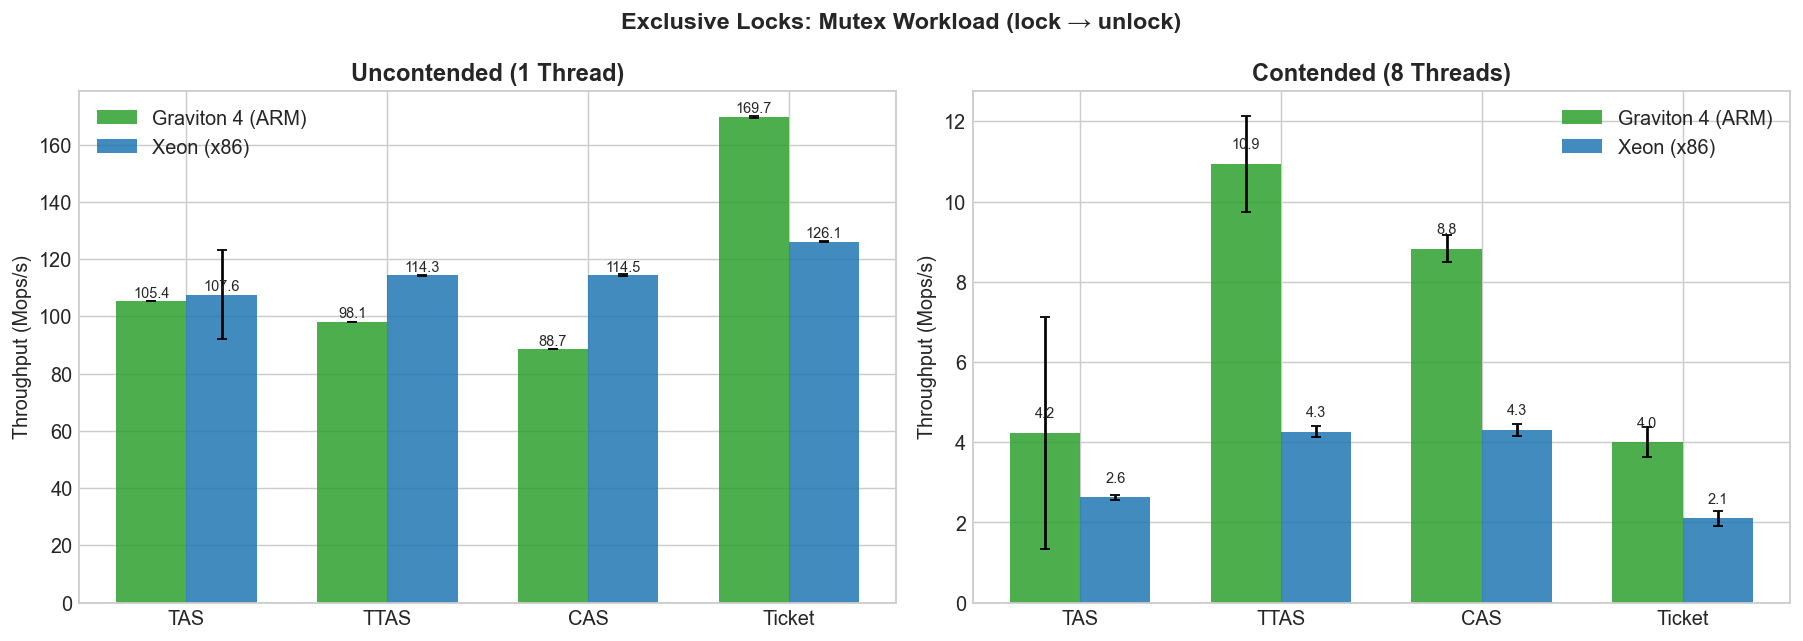

In [2]:
excl_locks = [l for l in ['tas','ttas','cas','ticket'] if l in mutex_locks]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, t, title in zip(axes, [1, 8], ['Uncontended (1 Thread)', 'Contended (8 Threads)']):
    sub = g_mutex[(g_mutex['threads']==t) & (g_mutex['lock'].isin(excl_locks))]
    x_pos = np.arange(len(excl_locks))
    w = 0.35
    for i, plat in enumerate(['arm','x86']):
        vals = sub[sub['platform']==plat].set_index('lock').reindex(excl_locks)
        bars = ax.bar(x_pos + i*w, vals['ops_m_mean'], w, yerr=vals['ops_m_std'],
                      label=PLAT_LABELS[plat], color=PLAT_COLORS[plat], capsize=3, alpha=0.85)
        for bar, v in zip(bars, vals['ops_m_mean']):
            if pd.notna(v) and v > 0:
                ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                        f'{v:.1f}', ha='center', va='bottom', fontsize=8)
    ax.set_xticks(x_pos + w/2)
    ax.set_xticklabels([LOCK_LABELS[l] for l in excl_locks])
    ax.set_ylabel('Throughput (Mops/s)')
    ax.set_title(title, fontweight='bold')
    ax.legend()

fig.suptitle('Exclusive Locks: Mutex Workload (lock → unlock)', fontsize=13, fontweight='bold')
fig.tight_layout()
plt.show()

## 2. Contention Retention

**Workload**: same mutex workload.
Retention = throughput(8T) / throughput(1T). Higher = scales better under contention.

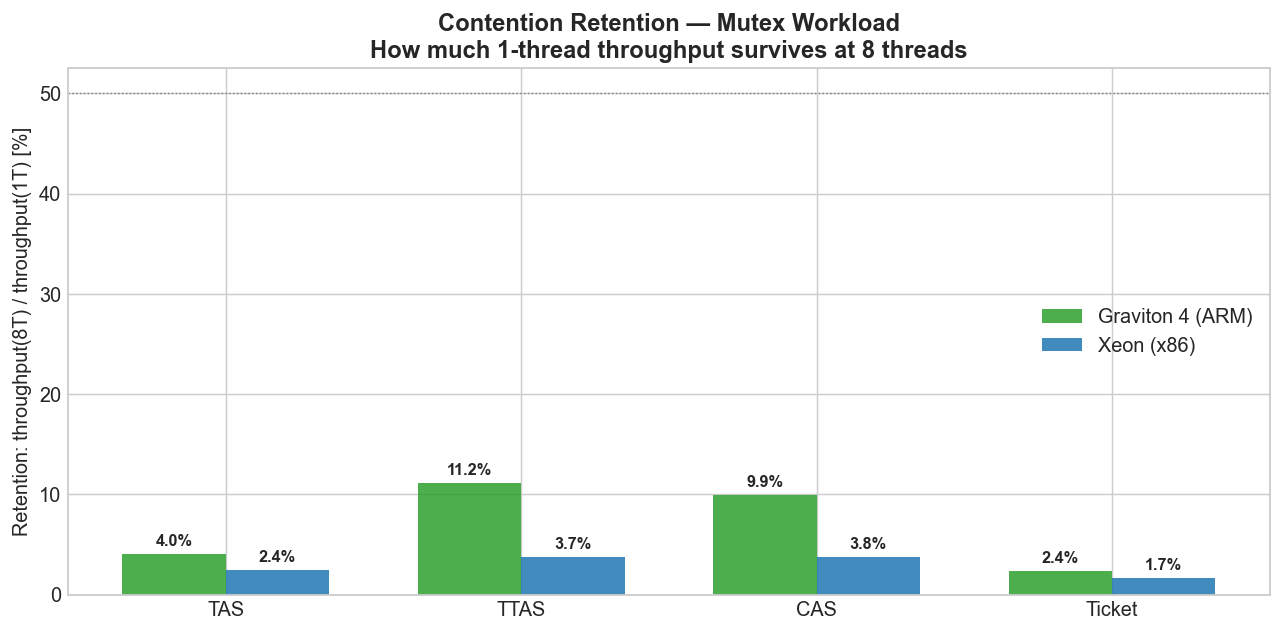

In [3]:
# Contention retention: 8T/1T ratio for exclusive locks
t1 = g_mutex[(g_mutex['threads']==1) & (g_mutex['lock'].isin(excl_locks))][['platform','lock','ops_m_mean']]
t1 = t1.rename(columns={'ops_m_mean':'t1'})
t8 = g_mutex[(g_mutex['threads']==8) & (g_mutex['lock'].isin(excl_locks))][['platform','lock','ops_m_mean']]
t8 = t8.rename(columns={'ops_m_mean':'t8'})
ret = t1.merge(t8, on=['platform','lock'])
ret['retention'] = ret['t8'] / ret['t1'] * 100

fig, ax = plt.subplots(figsize=(10, 5))
x_pos = np.arange(len(excl_locks))
w = 0.35
for i, plat in enumerate(['arm','x86']):
    vals = ret[ret['platform']==plat].set_index('lock').reindex(excl_locks)
    bars = ax.bar(x_pos + i*w, vals['retention'], w,
                  label=PLAT_LABELS[plat], color=PLAT_COLORS[plat], alpha=0.85)
    for bar, v in zip(bars, vals['retention']):
        if pd.notna(v):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                    f'{v:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x_pos + w/2)
ax.set_xticklabels([LOCK_LABELS[l] for l in excl_locks])
ax.set_ylabel('Retention: throughput(8T) / throughput(1T) [%]')
ax.set_title('Contention Retention — Mutex Workload\n'
             'How much 1-thread throughput survives at 8 threads', fontweight='bold')
ax.legend()
ax.axhline(50, color='gray', ls=':', lw=0.8, label='50% reference')
fig.tight_layout()
plt.show()

## 3. Radar
**Workload**: mutex, exclusive locks only.  
Each spoke is a lock. Value = throughput as % of the best lock at that thread count (100% = best).  

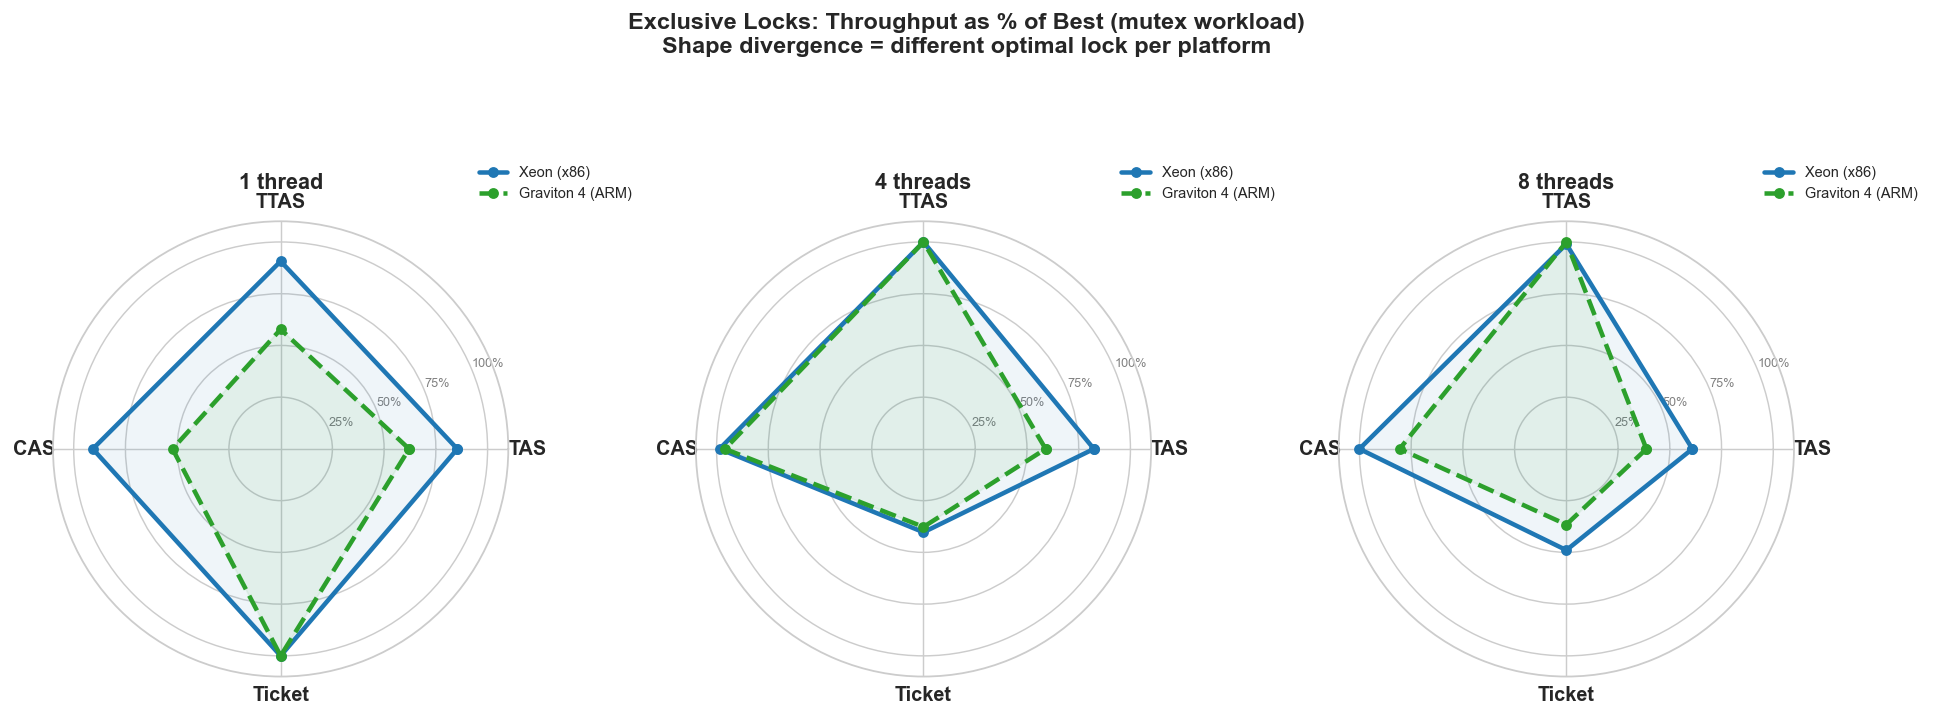

In [4]:
# Radar chart: normalized throughput per platform, exclusive locks only
KEY_T = [1, 4, 8]
n_spokes = len(excl_locks)
angles = np.linspace(0, 2*np.pi, n_spokes, endpoint=False).tolist() + [0]

norm = {}
for plat in ['arm','x86']:
    sub = g_mutex[(g_mutex['platform']==plat) & (g_mutex['lock'].isin(excl_locks))]
    tbl = sub.pivot(index='threads', columns='lock', values='ops_m_mean')[excl_locks]
    norm[plat] = tbl.div(tbl.max(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, len(KEY_T), figsize=(5*len(KEY_T), 5.5),
                         subplot_kw=dict(polar=True))
for ax, t in zip(axes, KEY_T):
    for plat, ls, lw in [('x86','-',2.5), ('arm','--',2.5)]:
        if t not in norm[plat].index: continue
        vals = [norm[plat].loc[t, l] for l in excl_locks] + [norm[plat].loc[t, excl_locks[0]]]
        ax.plot(angles, vals, color=PLAT_COLORS[plat], ls=ls, lw=lw,
                label=PLAT_LABELS[plat], marker='o', ms=5)
        ax.fill(angles, vals, color=PLAT_COLORS[plat], alpha=0.07)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([LOCK_LABELS[l] for l in excl_locks], fontweight='bold')
    ax.set_ylim(0, 110); ax.set_yticks([25,50,75,100])
    ax.set_yticklabels(['25%','50%','75%','100%'], fontsize=7, color='gray')
    ax.set_title(f'{t} thread{"s" if t>1 else ""}', fontsize=12, pad=18, fontweight='bold')
    ax.legend(fontsize=8, loc='upper right', bbox_to_anchor=(1.3, 1.15))

fig.suptitle('Exclusive Locks: Throughput as % of Best (mutex workload)\n'
             'Shape divergence = different optimal lock per platform',
             fontsize=13, fontweight='bold', y=1.06)
fig.tight_layout()
plt.show()

## 4. Read-Only Scaling: RW Primitives

**Workload**: `rw` / `rcu` with `read_pct=100`. RW, OCC, and RCU each run
their read path. Exclusive locks have no read path (they would simply
replay the mutex workload at 1/2/4/6/8 threads), so they are omitted here.

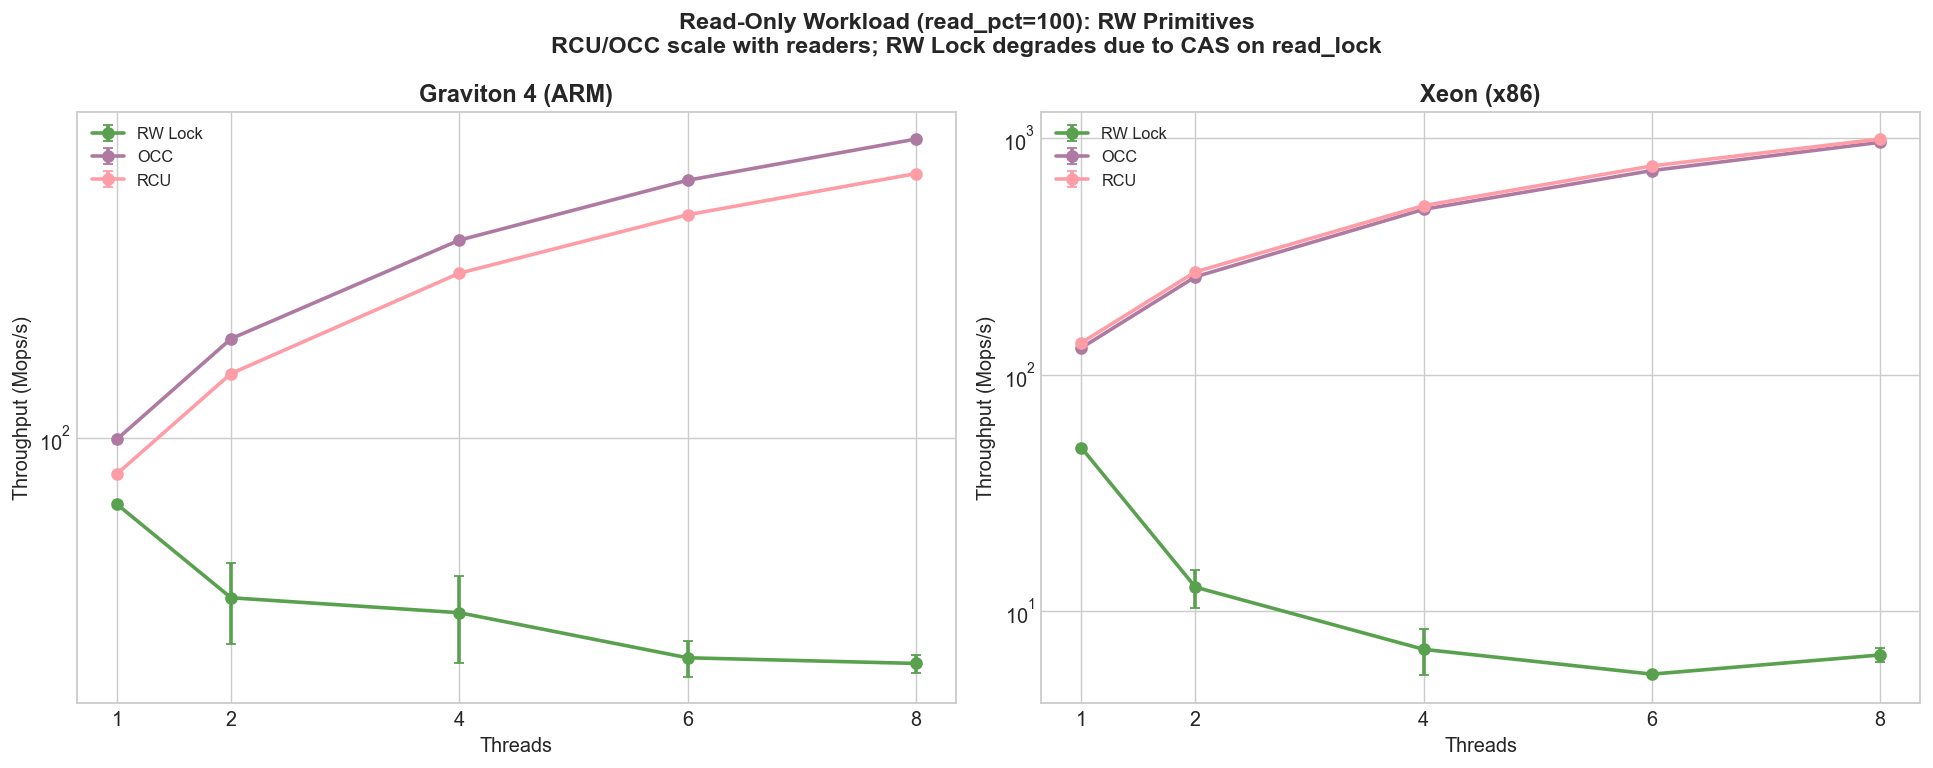

In [5]:
# Read-only scaling: rw/occ/rcu primitives only at read_pct=100.
# Exclusive locks (tas/ttas/cas/ticket) don't have a read path — they'd just
# replot the mutex workload — so they're excluded to keep the panel focused.
rw_prims = ['rw','occ','rcu']
rw_100 = all_df[(all_df['workload'].isin(['rw','rcu'])) & (all_df['read_pct']==100) &
                 (all_df['lock'].isin(rw_prims)) &
                 (all_df['threads'].isin(SHARED_THREADS))].copy()
g_read = agg(rw_100, ['platform','lock','threads'])

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, plat in zip(axes, ['arm','x86']):
    for lock in rw_prims:
        sub = g_read[(g_read['platform']==plat) & (g_read['lock']==lock)]
        if sub.empty: continue
        ax.errorbar(sub['threads'], sub['ops_m_mean'], yerr=sub['ops_m_std'],
                    label=LOCK_LABELS[lock], color=LOCK_COLORS[lock],
                    marker='o', lw=2, capsize=3)
    ax.set_xlabel('Threads')
    ax.set_ylabel('Throughput (Mops/s)')
    ax.set_title(PLAT_LABELS[plat], fontweight='bold')
    ax.set_xticks(SHARED_THREADS)
    ax.legend(fontsize=9)
    ax.set_yscale('log')

fig.suptitle('Read-Only Workload (read_pct=100): RW Primitives\n'
             'RCU/OCC scale with readers; RW Lock degrades due to CAS on read_lock',
             fontsize=13, fontweight='bold')
fig.tight_layout()
plt.show()

## 5. RW Primitives Across the Full Read-Mix Grid

**Workload**: `rw` / `rcu` workloads at every read split the CSV provides —
`read_pct ∈ {0, 50, 80, 95}`. (The 100% case is the focused panel in section 4.)

Reading left-to-right shows the handoff point: write-heavy mixes punish RW
lock's CAS-on-read; as reads dominate, OCC's zero-RMW read path and RCU's
epoch-based readers pull away.

read_pct splits used here: [0, 50, 80, 95]


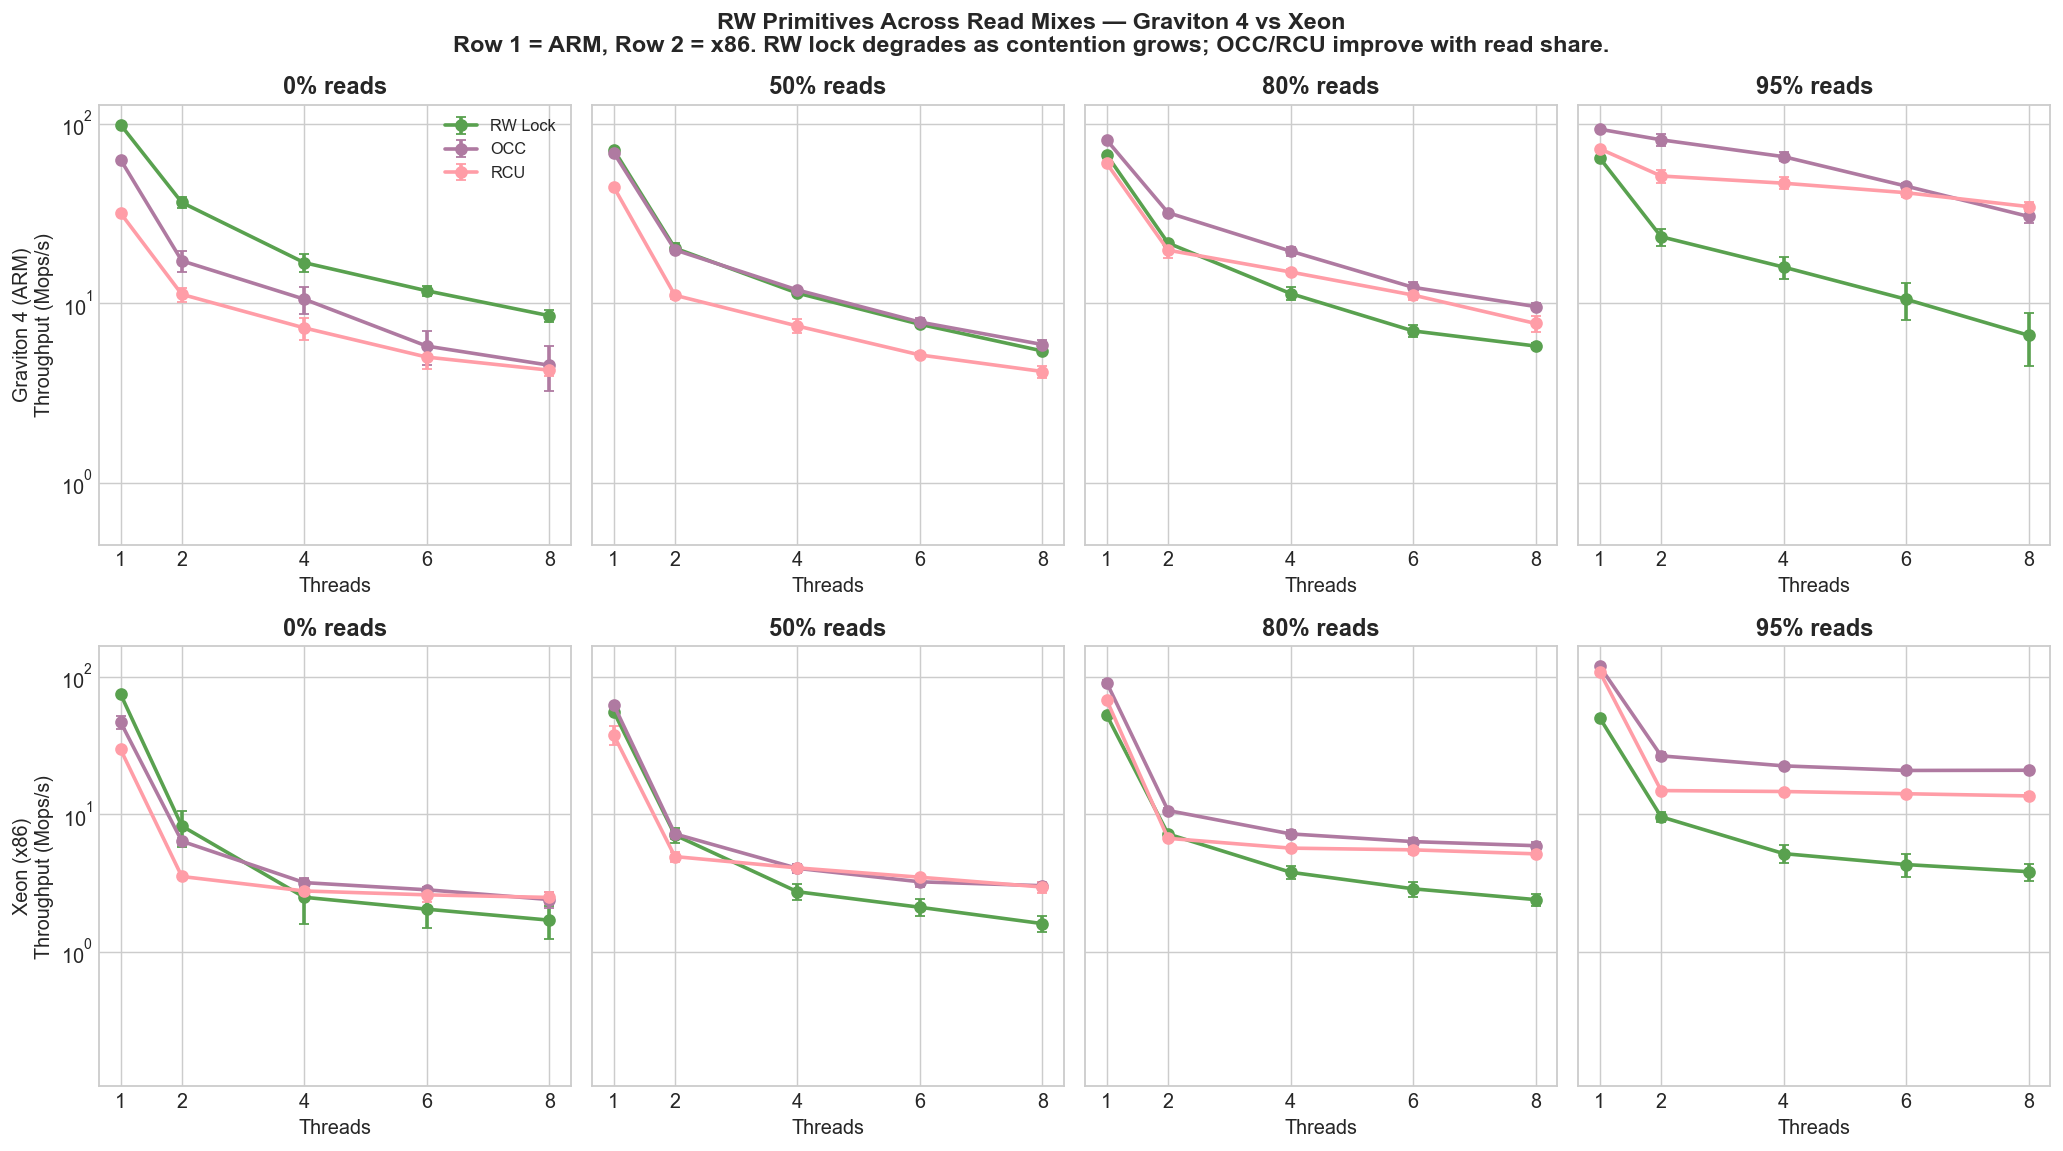

In [6]:
rw_prims = ['rw','occ','rcu']
# Use every read_pct the CSV has except 100 (covered in section 4).
read_pcts = sorted([int(r) for r in g_rwl['read_pct'].dropna().unique() if int(r) != 100])
print(f'read_pct splits used here: {read_pcts}')

fig, axes = plt.subplots(2, len(read_pcts), figsize=(4*len(read_pcts), 9), sharey='row')
if len(read_pcts) == 1:
    axes = axes[:, None]

for row, plat in enumerate(['arm','x86']):
    for col, rp in enumerate(read_pcts):
        ax = axes[row, col]
        for lock in rw_prims:
            sub = g_rwl[(g_rwl['platform']==plat) & (g_rwl['lock']==lock) &
                        (g_rwl['read_pct']==rp)]
            if sub.empty: continue
            ax.errorbar(sub['threads'], sub['ops_m_mean'], yerr=sub['ops_m_std'],
                        label=LOCK_LABELS[lock], color=LOCK_COLORS[lock],
                        marker='o', lw=2, capsize=3)
        ax.set_xticks(SHARED_THREADS)
        ax.set_xlabel('Threads')
        if col == 0:
            ax.set_ylabel(f'{PLAT_LABELS[plat]}\nThroughput (Mops/s)')
        ax.set_title(f'{rp}% reads', fontweight='bold')
        if row == 0 and col == 0:
            ax.legend(fontsize=9, loc='best')
        ax.set_yscale('log')

fig.suptitle('RW Primitives Across Read Mixes — Graviton 4 vs Xeon\n'
             'Row 1 = ARM, Row 2 = x86. RW lock degrades as contention grows; OCC/RCU improve with read share.',
             fontsize=13, fontweight='bold')
fig.tight_layout()
plt.show()

## 6. Fairness
**Workload**: mutex, 8 threads.  
Fairness = min per-thread ops / max per-thread ops (1.0 = all threads equal).  

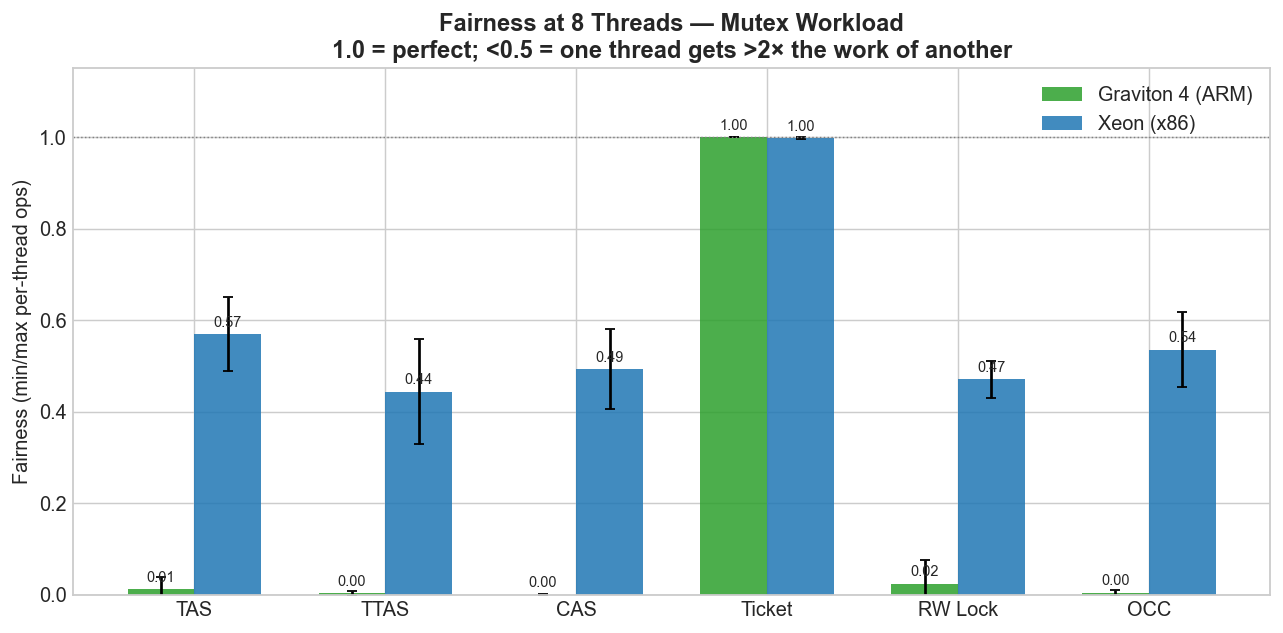

In [7]:
fair_locks = [l for l in LOCK_ORDER if l in g_mutex['lock'].unique()]
fair_8t = g_mutex[(g_mutex['threads']==8) & (g_mutex['lock'].isin(fair_locks))]

fig, ax = plt.subplots(figsize=(10, 5))
x_pos = np.arange(len(fair_locks))
w = 0.35
for i, plat in enumerate(['arm','x86']):
    vals = fair_8t[fair_8t['platform']==plat].set_index('lock').reindex(fair_locks)
    bars = ax.bar(x_pos + i*w, vals['fair_mean'], w, yerr=vals['fair_std'],
                  label=PLAT_LABELS[plat], color=PLAT_COLORS[plat], capsize=3, alpha=0.85)
    for bar, v in zip(bars, vals['fair_mean']):
        if pd.notna(v):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                    f'{v:.2f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x_pos + w/2)
ax.set_xticklabels([LOCK_LABELS[l] for l in fair_locks])
ax.set_ylabel('Fairness (min/max per-thread ops)')
ax.set_ylim(0, 1.15)
ax.axhline(1.0, color='gray', ls=':', lw=0.8)
ax.set_title('Fairness at 8 Threads — Mutex Workload\n'
             '1.0 = perfect; <0.5 = one thread gets >2× the work of another',
             fontweight='bold')
ax.legend()
fig.tight_layout()
plt.show()

## 7. Summary: All Ranking Differences at a Glance

Rank heatmap: for each thread count (mutex workload), rank 1 = fastest lock on that platform.  
The right panel shows rank *shift* (ARM rank minus x86 rank): blue = lock improves on ARM, red = degrades.

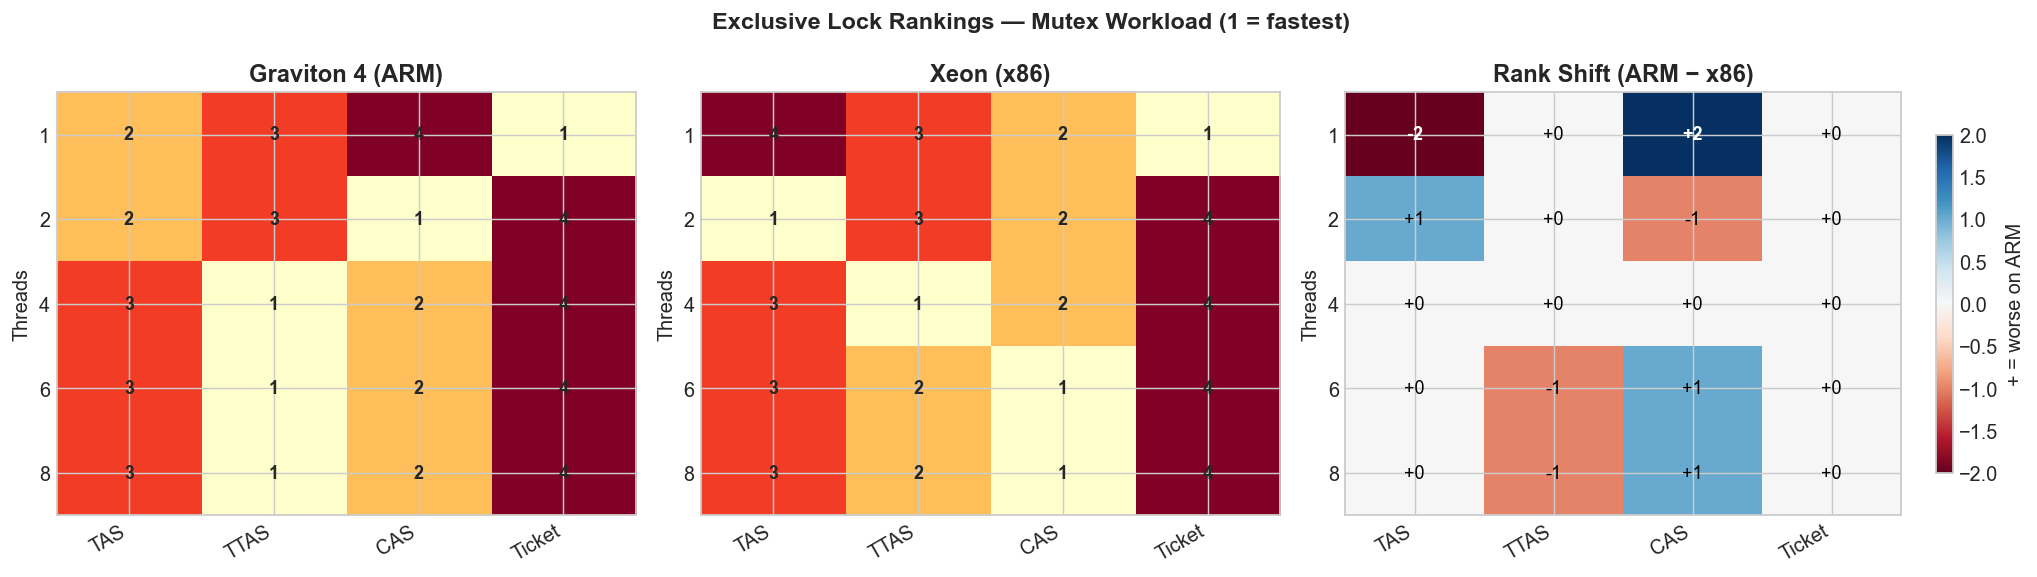

In [8]:
ranks = {}
for plat in ['arm','x86']:
    sub = g_mutex[(g_mutex['platform']==plat) & (g_mutex['lock'].isin(excl_locks))]
    tbl = sub.pivot(index='threads', columns='lock', values='ops_m_mean')[excl_locks]
    ranks[plat] = tbl.rank(axis=1, ascending=False).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5),
                         gridspec_kw={'width_ratios': [1, 1, 1.2]})

labels = [LOCK_LABELS[l] for l in excl_locks]
threads = sorted(ranks['arm'].index)

for ax, plat, title in zip(axes[:2], ['arm','x86'],
                           [PLAT_LABELS['arm'], PLAT_LABELS['x86']]):
    r = ranks[plat].loc[threads]
    im = ax.imshow(r.values, aspect='auto', cmap='YlOrRd', vmin=1, vmax=len(excl_locks))
    ax.set_xticks(range(len(excl_locks))); ax.set_xticklabels(labels, rotation=30, ha='right')
    ax.set_yticks(range(len(threads))); ax.set_yticklabels(threads)
    ax.set_ylabel('Threads'); ax.set_title(title, fontweight='bold')
    for i in range(len(threads)):
        for j in range(len(excl_locks)):
            ax.text(j, i, str(r.values[i,j]), ha='center', va='center', fontsize=10,
                    fontweight='bold')

# Rank difference
diff = (ranks['arm'] - ranks['x86']).loc[threads]
abs_max = max(abs(diff.values.min()), abs(diff.values.max()), 1)
im2 = axes[2].imshow(diff.values, aspect='auto', cmap='RdBu', vmin=-abs_max, vmax=abs_max)
axes[2].set_xticks(range(len(excl_locks))); axes[2].set_xticklabels(labels, rotation=30, ha='right')
axes[2].set_yticks(range(len(threads))); axes[2].set_yticklabels(threads)
axes[2].set_ylabel('Threads')
axes[2].set_title('Rank Shift (ARM − x86)', fontweight='bold')
for i in range(len(threads)):
    for j in range(len(excl_locks)):
        v = diff.values[i,j]
        axes[2].text(j, i, f'{v:+d}', ha='center', va='center', fontsize=10,
                     fontweight='bold' if abs(v)>=2 else 'normal',
                     color='white' if abs(v)>=abs_max*0.6 else 'black')
fig.colorbar(im2, ax=axes[2], label='+ = worse on ARM', shrink=0.8)

fig.suptitle('Exclusive Lock Rankings — Mutex Workload (1 = fastest)',
             fontsize=13, fontweight='bold')
fig.tight_layout()
plt.show()